In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [4]:
uploads = files.upload()

Saving img_escura.jpeg to img_escura.jpeg
Saving img_clara.jpeg to img_clara.jpeg
Saving img_bem_exposta.jpeg to img_bem_exposta.jpeg


In [7]:
img_escura = cv2.imread('img_escura.jpeg')
img_clara = cv2.imread('img_clara.jpeg')
img_bem_exposta = cv2.imread('img_bem_exposta.jpeg')

img_escura_gray = cv2.cvtColor(img_escura, cv2.COLOR_BGR2GRAY)
img_clara_gray = cv2.cvtColor(img_clara, cv2.COLOR_BGR2GRAY)
img_bem_exposta_gray = cv2.cvtColor(img_bem_exposta, cv2.COLOR_BGR2GRAY)

In [9]:
def calc_hist(img):
  img_vetor = img.ravel()
  hist_vetor = np.zeros(256)

  for px in img_vetor:
    hist_vetor[px] += 1

  return hist_vetor

def corrigir_gamma(img, gamma):
  img_normalizada = img / 255.0
  img_corrigida = 255 * (img_normalizada ** gamma)
  return np.uint8(img_corrigida)

def expandir_contraste(img, L, H):
  resultado = (img.astype(float) - L) * 255 / (H - L)
  resultado = np.clip(resultado, 0, 255)
  return np.uint8(resultado)

## 1. Imagem escura

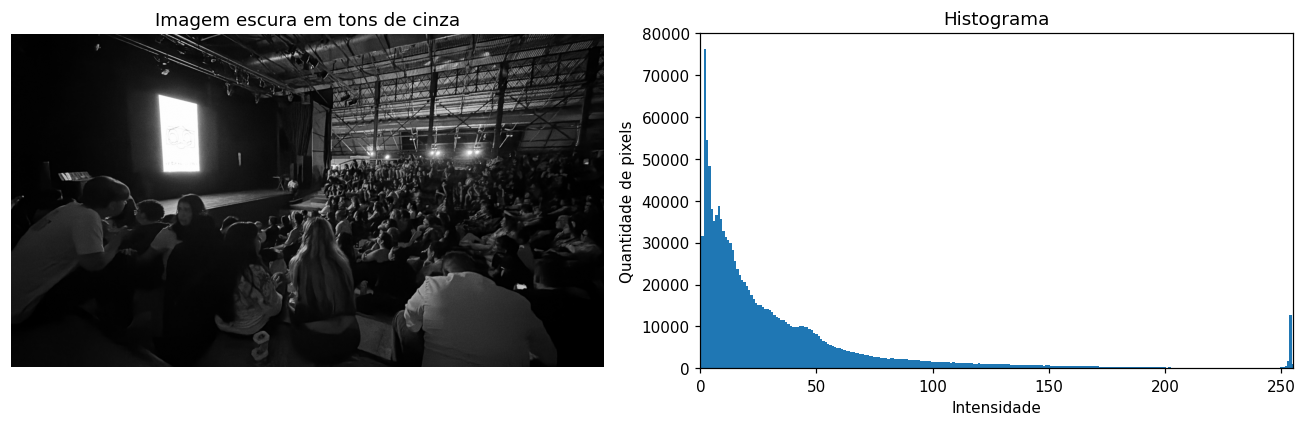

In [ ]:
hist_escura = calc_hist(img_escura_gray)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.imshow(img_escura_gray, cmap='gray')
plt.title('Imagem escura em tons de cinza')
plt.axis('off')

plt.subplot(1,2,2)
plt.bar(range(256), hist_escura)
plt.title('Histograma')
plt.xlabel('Intensidade')
plt.ylabel('Quantidade de pixels')
plt.show()

O histograma está concentrado principalmente nas intensidades baixas abaixo de 50. Isso mostra que a maior parte da imagem possui tons escuros e pouca iluminação.


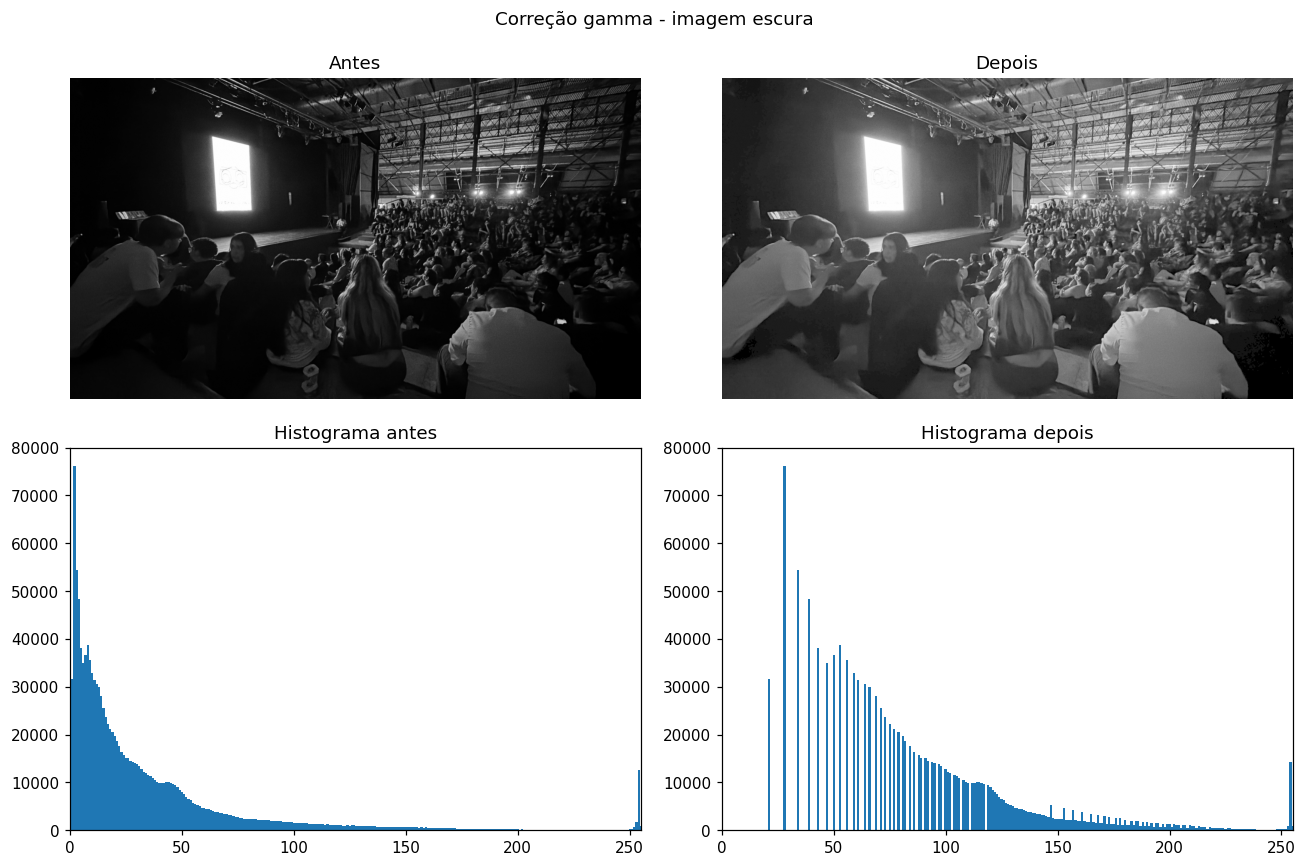

In [ ]:
img_escura_corrigida = corrigir_gamma(img_escura_gray, 0.45)

plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.imshow(img_escura_gray, cmap='gray')
plt.title('Antes')
plt.axis('off')
plt.subplot(2,2,2)
plt.imshow(img_escura_corrigida, cmap='gray')
plt.title('Depois')
plt.axis('off')
plt.subplot(2,2,3)
plt.bar(range(256), calc_hist(img_escura_gray))
plt.title('Histograma antes')
plt.subplot(2,2,4)
plt.bar(range(256), calc_hist(img_escura_corrigida))
plt.title('Histograma depois')
plt.show()

Foi usada a **correção gamma com γ = 0,45**. Como o valor de gamma é menor que 1, os tons escuros são clareados e os detalhes ficam mais visíveis.

## 2. Imagem clara ou saturada

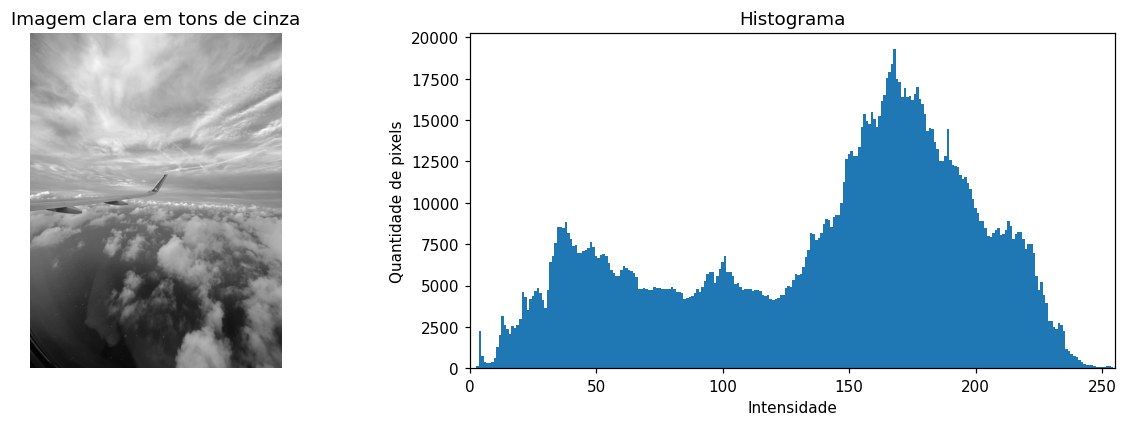

In [ ]:
hist_clara = calc_hist(img_clara_gray)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.imshow(img_clara_gray, cmap='gray')
plt.title('Imagem clara em tons de cinza')
plt.axis('off')

plt.subplot(1,2,2)
plt.bar(range(256), hist_clara)
plt.title('Histograma')
plt.xlabel('Intensidade')
plt.ylabel('Quantidade de pixels')
plt.show()

O histograma se concentra entre as faixas de intensidade 150 e 200, isso se da pela cor do céu e da reflexão da luz nas núvens



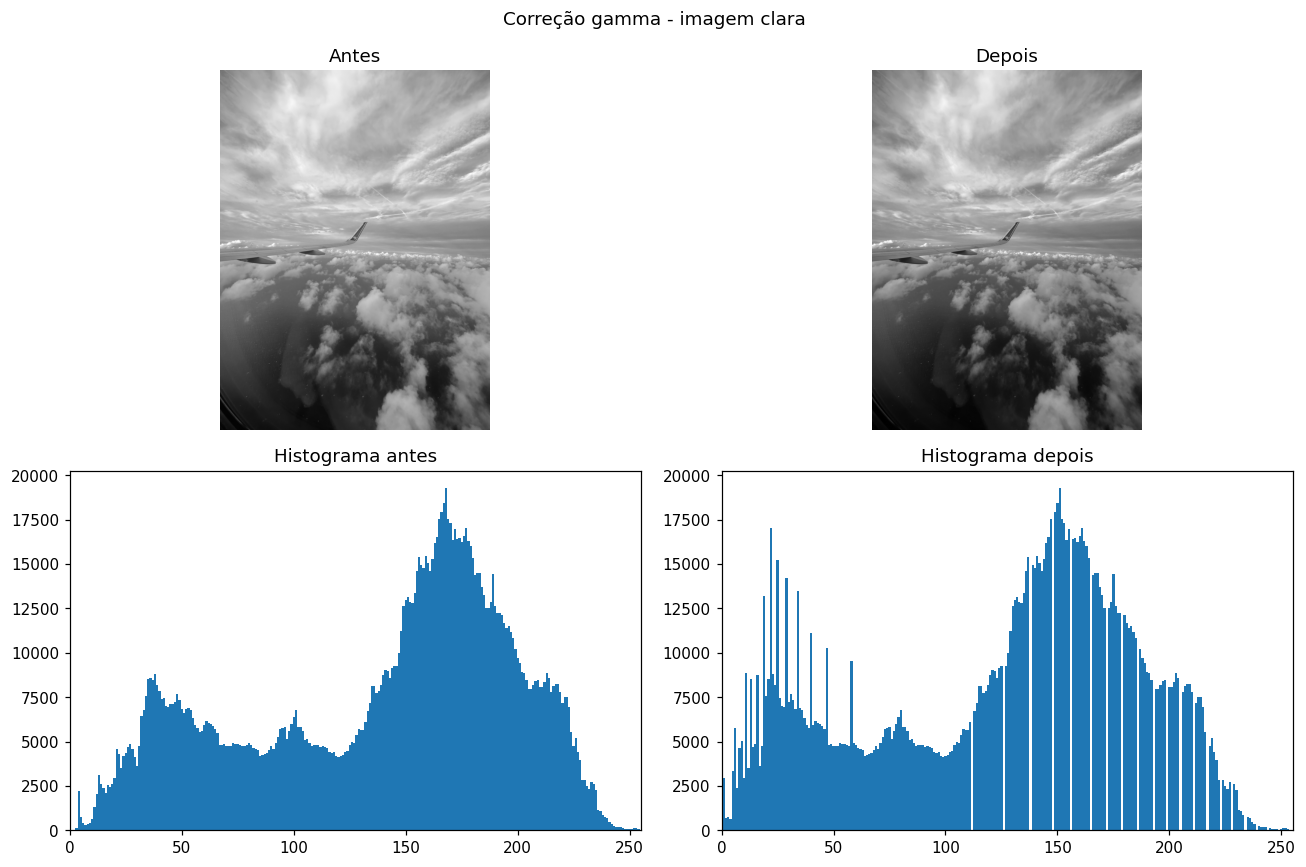

In [ ]:
img_clara_corrigida = corrigir_gamma(img_clara_gray, 1.25)

plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.imshow(img_clara_gray, cmap='gray')
plt.title('Antes')
plt.axis('off')
plt.subplot(2,2,2)
plt.imshow(img_clara_corrigida, cmap='gray')
plt.title('Depois')
plt.axis('off')
plt.subplot(2,2,3)
plt.bar(range(256), calc_hist(img_clara_gray))
plt.title('Histograma antes')
plt.subplot(2,2,4)
plt.bar(range(256), calc_hist(img_clara_corrigida))
plt.title('Histograma depois')
plt.show()

Foi usada a **correção gamma com γ = 1,25**. Como o valor é maior que 1, a operação escurece um pouco os tons claros e melhora a visualização das nuvens.

## 3. Imagem bem exposta

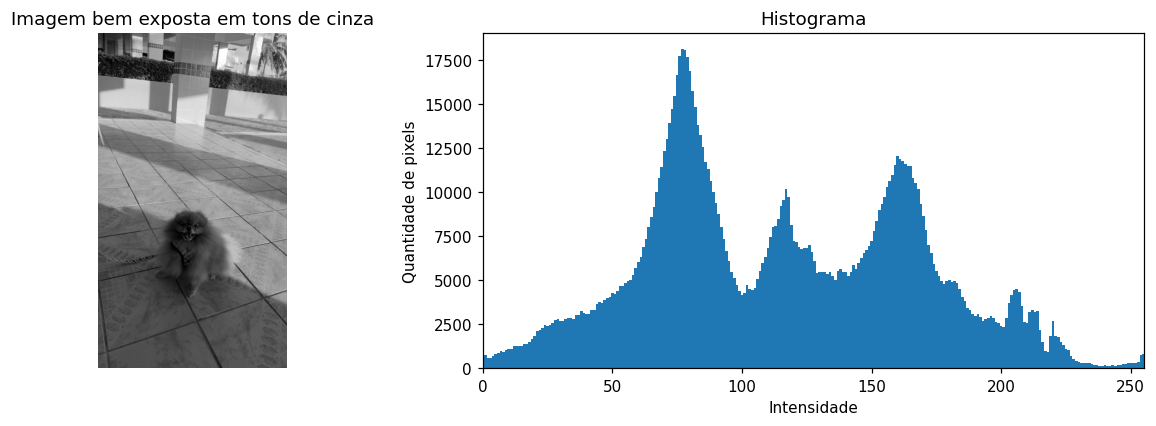

In [ ]:
hist_bem_exposta = calc_hist(img_bem_exposta_gray)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.imshow(img_bem_exposta_gray, cmap='gray')
plt.title('Imagem bem exposta em tons de cinza')
plt.axis('off')

plt.subplot(1,2,2)
plt.bar(range(256), hist_bem_exposta)
plt.title('Histograma')
plt.xlabel('Intensidade')
plt.ylabel('Quantidade de pixels')
plt.show()

Nessa imagem percebe-se um equilibrio na intensidade distribuida em tons médios onde a exposição da luz e sombras estão controladas



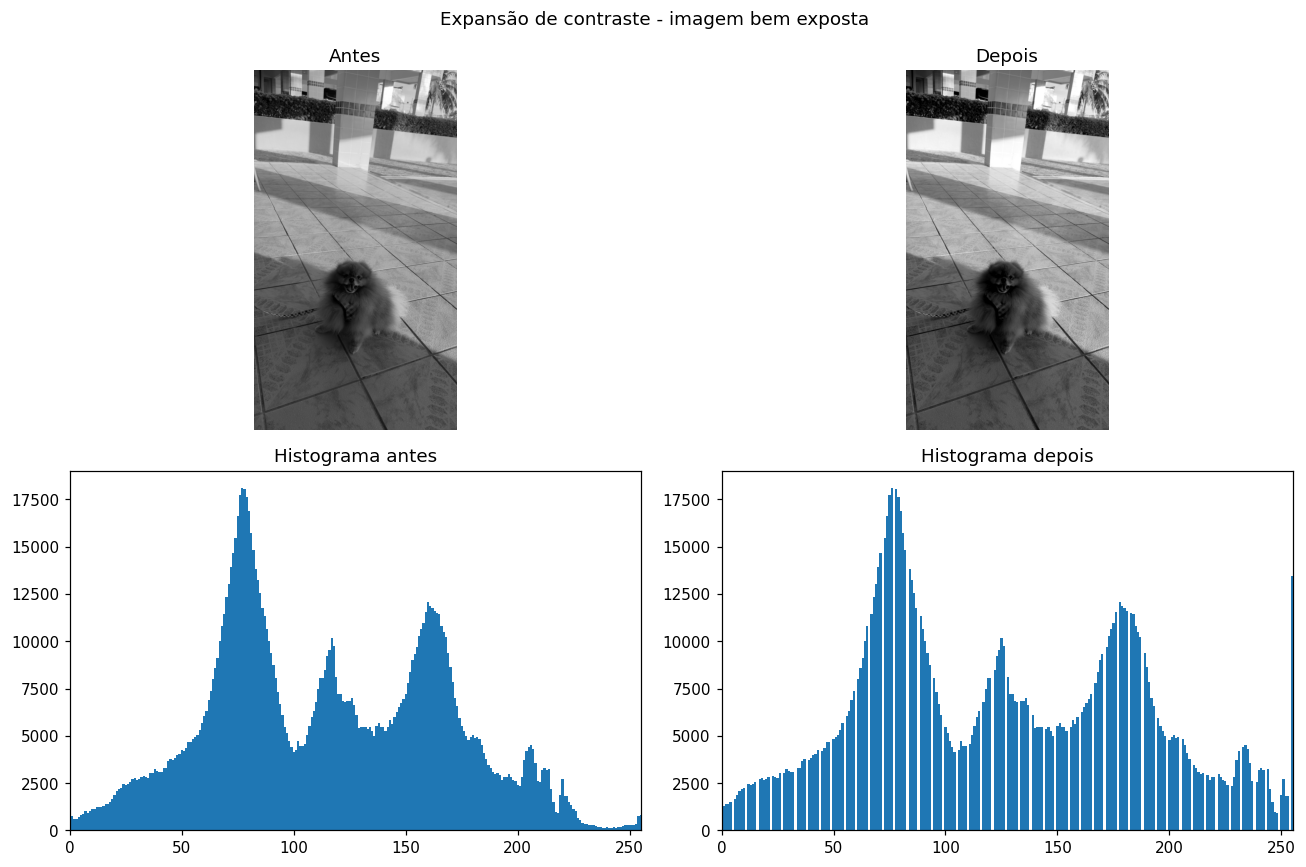

In [ ]:
img_bem_exposta_corrigida = expandir_contraste(img_bem_exposta_gray, 14, 223)

plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.imshow(img_bem_exposta_gray, cmap='gray')
plt.title('Antes')
plt.axis('off')
plt.subplot(2,2,2)
plt.imshow(img_bem_exposta_corrigida, cmap='gray')
plt.title('Depois')
plt.axis('off')
plt.subplot(2,2,3)
plt.bar(range(256), calc_hist(img_bem_exposta_gray))
plt.title('Histograma antes')
plt.subplot(2,2,4)
plt.bar(range(256), calc_hist(img_bem_exposta_corrigida))
plt.title('Histograma depois')
plt.show()

Foi usada uma **expansão de contraste com L = 14 e H = 223**. Esses limites aumentam levemente o contraste sem alterar demais uma imagem que já estava bem exposta.

A operação fez menos diferença na imagem bem exposta, pois ela já possuía uma boa distribuição das intensidades. A expansão apenas aumentou um pouco o contraste. Na imagem escura a mudança foi maior, porque a correção gamma deslocou vários tons para intensidades mais claras.